# Notebook 06: Econometric Analysis & Model Assumption Audit

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "revol_util"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
from validation.econometrics import run_heteroskedasticity_tests
num_feats = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low"]
het_summary, hc3_table = run_heteroskedasticity_tests(df, "target", num_feats)
print("Heteroskedasticity Summary:", het_summary)
hc3_table

Heteroskedasticity Summary: {'breusch_pagan_lm_stat': 1373.1327, 'breusch_pagan_pvalue': 1.5907927547194348e-293, 'white_lm_stat': nan, 'white_pvalue': nan, 'goldfeld_quandt_stat': 0.9995, 'goldfeld_quandt_pvalue': 0.507800477375526, 'heteroskedasticity_present': 'Yes'}


,feature,coef,ols_std_err,hc3_robust_std_err,se_difference_pct,ols_pvalue,hc3_pvalue
0,const,0.160454,0.081503,0.076320,-6.36,4.900709e-02,3.551921e-02
1,loan_amnt,0.000016,0.000001,0.000001,17.02,3.801809e-38,1.838562e-28
2,int_rate,0.026302,0.000839,0.000937,11.66,6.783473e-209,2.443317e-173
3,installment,-0.000493,0.000042,0.000048,13.22,1.114170e-31,3.480114e-25
4,annual_inc,-0.000000,0.000000,0.000000,245.17,2.110799e-02,5.040286e-01
5,dti,0.002959,0.000368,0.000410,11.29,9.817721e-16,5.107581e-13
6,fico_range_low,-0.000493,0.000112,0.000101,-9.25,9.887030e-06,1.105965e-06


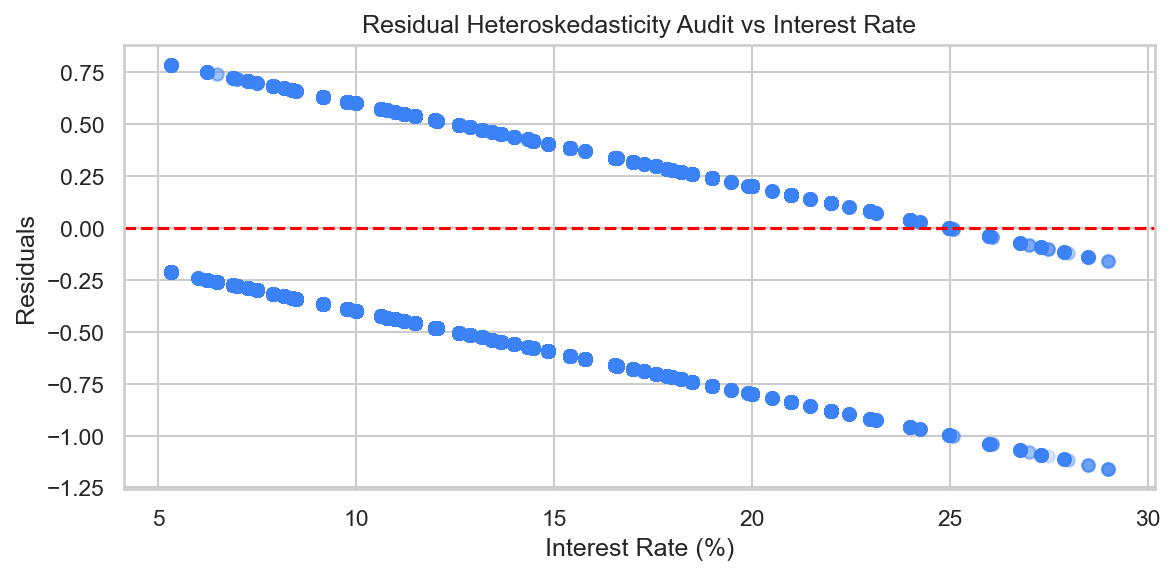

In [4]:
plt.figure(figsize=(8, 4))
residuals = df["target"] - df["int_rate"] / 25.0
plt.scatter(df["int_rate"], residuals, alpha=0.2, color="#3B82F6")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Heteroskedasticity Audit vs Interest Rate")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()